# Lecture 10 (file family L09) · Boxes, IoU, matching and AP from scratch

**One toy geometry-and-evaluation pipeline.** You will convert a box, implement IoU, inspect a training loss, match scored predictions to two ground-truth objects, build precision–recall points, and verify anchor encode/decode.

Work in this rhythm: **predict → calculate → run → inspect → explain**. All examples are deterministic and use only NumPy and Matplotlib.

**Clock map:** `TRAIN` compares predictions with assigned targets; `INFER` decodes boxes and scores; `EVAL` matches a frozen ranked list to ground truth. This notebook crosses `TRAIN → EVAL`; the companion NMS notebook owns the `INFER` clock.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.set_printoptions(precision=3, suppress=True)
TEAL, ORANGE, GREEN, RED = '#2A7F7F', '#F57C00', '#20A84A', '#E34850'

## 1 · Convert and normalize a box

A cat occupies corner-form box $[160,96,480,336]$ in a $640\times480$ image.

**Predict before running:** what are $(x_c,y_c,w,h)$ in pixels? Which three normalized coordinates equal $0.5$?

In [2]:
W, H = 640, 480
corner = np.array([160., 96., 480., 336.])
xmin, ymin, xmax, ymax = corner
center_size = np.array([(xmin+xmax)/2, (ymin+ymax)/2, xmax-xmin, ymax-ymin])
normalized = center_size / np.array([W, H, W, H])
print('center-size pixels :', center_size)
print('normalized target  :', normalized)
assert np.allclose(center_size, [320, 216, 320, 240])
assert np.allclose(normalized, [0.50, 0.45, 0.50, 0.50])

center-size pixels : [320. 216. 320. 240.]
normalized target  : [0.5  0.45 0.5  0.5 ]


## 2 · Implement IoU safely

Boxes use corner form $[x_{min},y_{min},x_{max},y_{max}]$ with **continuous/half-open edges**: width is $x_{max}-x_{min}$, with no inclusive-pixel `+1`. The intersection width and height must be clamped at zero.

**Calculate first:** for $A=[0,0,10,10]$ and $B=[5,5,15,15]$, find intersection area, union area and IoU.

In [3]:
def box_area(box):
    x0, y0, x1, y1 = box
    return max(0.0, x1-x0) * max(0.0, y1-y0)

def iou(a, b, return_parts=False):
    left, top = max(a[0], b[0]), max(a[1], b[1])
    right, bottom = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, right-left), max(0.0, bottom-top)
    inter = iw * ih
    union = box_area(a) + box_area(b) - inter
    value = inter / union if union > 0 else 0.0
    return (value, inter, union) if return_parts else value

A = np.array([0., 0., 10., 10.])
B = np.array([5., 5., 15., 15.])
value, inter, union = iou(A, B, return_parts=True)
print(f'intersection={inter:.0f}, union={union:.0f}, IoU={value:.3f}')
assert np.isclose(value, 25/175)
assert iou(A, np.array([20., 20., 30., 30.])) == 0.0

intersection=25, union=175, IoU=0.143


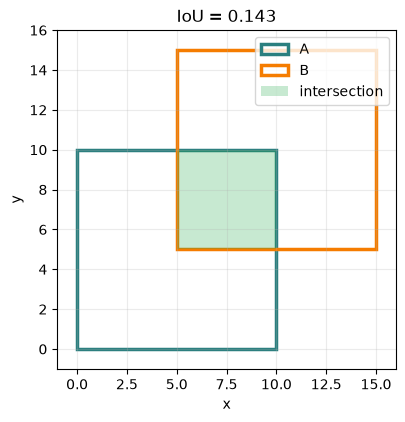

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for box, color, label in [(A, TEAL, 'A'), (B, ORANGE, 'B')]:
    x0, y0, x1, y1 = box
    ax.add_patch(Rectangle((x0,y0), x1-x0, y1-y0, fill=False, lw=2.5, ec=color, label=label))
ax.add_patch(Rectangle((5,5), 5, 5, fc=GREEN, alpha=.25, ec='none', label='intersection'))
ax.set(xlim=(-1,16), ylim=(-1,16), xlabel='x', ylabel='y', title=f'IoU = {value:.3f}')
ax.set_aspect('equal'); ax.grid(alpha=.25); ax.legend(); plt.show()

## 3 · `TRAIN` — coordinate loss and overlap answer different questions

The normalized target is $b=(0.50,0.45,0.50,0.50)$ and the prediction is $\hat b=(0.55,0.40,0.60,0.45)$.

**Predict:** the $L_1$ sum is $0.25$. Will smooth-$L_1$ be larger or smaller when every residual has magnitude below 1?

In [5]:
b_true = np.array([0.50, 0.45, 0.50, 0.50])
b_pred = np.array([0.55, 0.40, 0.60, 0.45])
residual = b_pred - b_true

def smooth_l1(r):
    a = np.abs(r)
    return np.where(a < 1, 0.5*r*r, a-0.5)

print('residuals        :', residual)
print('L1 sum           :', np.abs(residual).sum())
print('smooth-L1 sum    :', smooth_l1(residual).sum())

def center_to_corner(box):
    xc, yc, w, h = box
    return np.array([xc-w/2, yc-h/2, xc+w/2, yc+h/2])

pair_iou = iou(center_to_corner(b_true), center_to_corner(b_pred))
print('IoU, same pair   :', pair_iou)
print('classification CE:', -np.log(0.80))
print('total, lambda=2  :', -np.log(0.80) + 2*np.abs(residual).sum())
assert np.isclose(pair_iou, 0.2125/0.3075)

residuals        : [ 0.05 -0.05  0.1  -0.05]
L1 sum           : 0.25
smooth-L1 sum    : 0.008749999999999997
IoU, same pair   : 0.6910569105691055
classification CE: 0.2231435513142097
total, lambda=2  : 0.7231435513142097


## 4 · `EVAL` — match predictions one-to-one

Our held image contains two ground-truth cups, $G_1$ and $G_2$. `INFER` began with A, B, E, C, D, then NMS returned A, E, C. On the `EVAL` clock, each returned detection claims the best **unmatched** truth at $IoU \ge \tau$.

**Predict:** which of returned detections A, E, C are true positives? Why can NMS not know that E is a false alarm?

In [6]:
gt = np.array([[10,10,50,50], [60,15,90,55]], float)
raw_pred = np.array([
    [10,10,50,50],   # A: exact G1
    [12,12,52,52],   # B: duplicate G1
    [35, 5,55,25],   # E: false alarm
    [60,15,90,55],   # C: exact G2
    [63,17,91,56],   # D: duplicate G2
], float)
raw_names = np.array(['A','B','E','C','D'])
raw_scores = np.array([.95,.90,.89,.88,.75])
returned_idx = np.array([0,2,3])  # NMS at tau=.50 keeps A, E, C
pred, names, scores = raw_pred[returned_idx], raw_names[returned_idx], raw_scores[returned_idx]
iou_matrix = np.array([[iou(p,g) for g in gt] for p in pred])
print('raw candidates :', raw_names.tolist())
print('NMS returned   :', names.tolist())
print('EVAL rows A,E,C; columns G1,G2')
print(iou_matrix)

raw candidates : ['A', 'B', 'E', 'C', 'D']
NMS returned   : ['A', 'E', 'C']
EVAL rows A,E,C; columns G1,G2
[[1.    0.   ]
 [0.127 0.   ]
 [0.    1.   ]]


In [7]:
def greedy_match(iou_matrix, threshold=0.5):
    used_truths = set()
    is_tp, claimed = [], []
    for row in iou_matrix:              # predictions already score-sorted
        available = [j for j in range(len(row)) if j not in used_truths]
        if not available:
            is_tp.append(False)
            claimed.append(None)
            continue
        j = max(available, key=lambda candidate: row[candidate])
        ok = row[j] >= threshold
        is_tp.append(ok)
        claimed.append(j if ok else None)
        if ok: used_truths.add(j)
    return np.array(is_tp), claimed

is_tp, claimed = greedy_match(iou_matrix, threshold=.5)
for name, score, row, tp, claim in zip(names, scores, iou_matrix, is_tp, claimed):
    result = f'TP, claims G{claim+1}' if tp else 'FP'
    print(f'{name}: score={score:.2f}, best IoU={row.max():.3f} -> {result}')
assert is_tp.tolist() == [True, False, True]
assert claimed == [0, None, 1]

# Regression test: the second prediction must be allowed to claim its second-best, unmatched truth.
edge_tp, edge_claimed = greedy_match(np.array([[.90, .00], [.90, .80]]), threshold=.5)
assert edge_tp.tolist() == [True, True] and edge_claimed == [0, 1]

A: score=0.95, best IoU=1.000 -> TP, claims G1
E: score=0.89, best IoU=0.127 -> FP
C: score=0.88, best IoU=1.000 -> TP, claims G2


## 5 · `EVAL` — build precision–recall points from the ranking

After each prediction enters, recompute cumulative TP, precision and recall.

**Calculate first:** E enters between A and C. What happens to precision before C raises recall from $1/2$ to $1$?

We report **rank AP@0.50 for one class**: average precision at ranks where recall increases. This is not COCO mAP; COCO interpolates precision at 101 recall points, then averages over classes and IoU thresholds $0.50{:}0.95$.

In [8]:
tp_cum = np.cumsum(is_tp)
fp_cum = np.cumsum(~is_tp)
precision = tp_cum / (tp_cum + fp_cum)
recall = tp_cum / len(gt)
for n, p, r in zip(names, precision, recall):
    print(f'after {n}: precision={p:.3f}, recall={r:.3f}')

# One-class rank AP@0.50: average precision at ranks where a new TP appears.
ap = precision[is_tp].sum() / len(gt)
print(f'rank AP@0.50 = ({precision[is_tp][0]:.3f} + {precision[is_tp][1]:.3f}) / 2 = {ap:.3f}')
assert np.isclose(ap, 5/6)

after A: precision=1.000, recall=0.500
after E: precision=0.500, recall=0.500
after C: precision=0.667, recall=1.000
rank AP@0.50 = (1.000 + 0.667) / 2 = 0.833


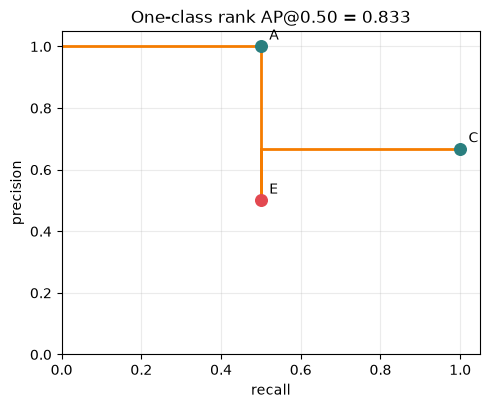

In [9]:
fig, ax = plt.subplots(figsize=(5.4,4.2))
# `pre` makes each recall interval use the precision at the rank that reaches it.
ax.step(np.r_[0, recall], np.r_[1, precision], where='pre', color=ORANGE, lw=2)
for n, r, p in zip(names, recall, precision):
    ax.scatter(r,p,color=TEAL if n in ['A','C'] else RED, s=70, zorder=3)
    ax.annotate(n,(r,p),xytext=(6,5),textcoords='offset points')
ax.set(xlim=(0,1.05), ylim=(0,1.05), xlabel='recall', ylabel='precision', title=f'One-class rank AP@0.50 = {ap:.3f}')
ax.grid(alpha=.25); plt.show()

## 6 · `TRAIN ↔ INFER` — encode and decode one anchor

Anchor $a=(50,50,40,40)$ and matched box $b=(58,46,80,40)$ use center-size form.

**Predict:** which offset is zero? Which offset is $\log 2$?

In [10]:
def encode(anchor, box):
    xa, ya, wa, ha = anchor
    x, y, w, h = box
    return np.array([(x-xa)/wa, (y-ya)/ha, np.log(w/wa), np.log(h/ha)])

def decode(anchor, t):
    xa, ya, wa, ha = anchor
    tx, ty, tw, th = t
    return np.array([xa+tx*wa, ya+ty*ha, wa*np.exp(tw), ha*np.exp(th)])

anchor = np.array([50.,50.,40.,40.])
target = np.array([58.,46.,80.,40.])
offset = encode(anchor, target)
recovered = decode(anchor, offset)
print('encoded offsets:', offset)
print('decoded box    :', recovered)
assert np.allclose(recovered, target)

encoded offsets: [ 0.2   -0.1    0.693  0.   ]
decoded box    : [58. 46. 80. 40.]


## Explain, do not merely report

In two or three sentences each:

1. Why are duplicate candidates B and D absent from the `EVAL` ranked list?
2. Why is E a false positive even though it survived NMS?
3. What does the score control during AP evaluation, and what does the IoU threshold control?
4. Why regress offsets from an anchor rather than unconstrained raw pixel coordinates?

## Takeaway

- A box is four numbers, but IoU measures the geometry those numbers create.
- Detection evaluation is **ranked, class-aware and one-to-one**; duplicates are false positives.
- `TRAIN` uses assigned targets and losses; `INFER` decodes; `EVAL` performs one-to-one matching on a frozen ranked list.
- Rank AP@0.50 summarizes this one-class ranking; COCO mAP uses a broader interpolation-and-averaging protocol.
- Anchor offsets are a well-scaled parameterization for learning box corrections.